#**DHI Dataset Complete Experiments**


##**Common Setup (For all algorithms)**

In [ ]:
# --------------------------
# Robust preprocessing (standalone for each block)
# --------------------------
# Copy this entire cell at the top of each algorithm-block (it's included below inside each block).
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.2
USE_SMOTE = False   # set True if you want to enable SMOTE in a specific block

# --- Load dhi.csv (tries current working dir, else prompts upload) ---
if os.path.exists('/content/dhi.csv'):
    df = pd.read_csv('/content/dhi.csv')
elif os.path.exists('dhi.csv'):
    df = pd.read_csv('dhi.csv')
else:
    from google.colab import files
    uploaded = files.upload()
    # pick first filename
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)

# --- Normalize column names ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# --- Detect target column (case-insensitive match to "diabetes") ---
target_candidates = [c for c in df.columns if c.lower() == 'diabetes' or 'diabet' in c.lower()]
if len(target_candidates) == 0:
    raise ValueError("Target column containing 'diabetes' not found. Available columns: {}".format(list(df.columns)))
target_col = target_candidates[0]
print("Using target column:", target_col)

# --- Clean common missing tokens and strip strings ---
df.replace(['?', 'NA', 'N/A', 'na', 'null', 'None', ''], np.nan, inplace=True)
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# --- Standardize Yes/No columns to 1/0 where applicable ---
for col in df.columns:
    if df[col].dropna().astype(str).isin(['Yes','No','YES','NO','yes','no']).all():
        df[col] = df[col].astype(str).str.strip().str.lower().map({'yes':1,'no':0})

# --- Standardize Gender if present ---
if 'gender' in df.columns:
    df['gender'] = df['gender'].astype(str).str.strip().str.lower().map({'male':1,'female':0})

# --- Handle textual age ranges if present (map common patterns) ---
if 'age' in df.columns and df['age'].dtype == object:
    # map several common textual forms to ordinal numeric categories
    df['age'] = df['age'].str.strip().str.lower()
    age_map = {
        'less than 40': 1, '<40':1, 'below 40':1,
        '40-49': 2, '40 – 49':2, '40–49':2, '40s':2,
        '50-59':3, '50s':3, '50 – 59':3, '50–59':3,
        '60 or older':4, '60+':4, '60_and_above':4, '60 or above':4
    }
    df['age'] = df['age'].map(lambda x: age_map.get(x, x))
    # if still object (like '45' as string) convert numeric strings to numbers when possible
    df['age'] = pd.to_numeric(df['age'], errors='ignore')

# --- Convert numeric strings to numeric types where possible ---
for col in df.columns:
    # keep target as-is for now
    if col == target_col: continue
    # if column is object but contains numeric-like strings, coerce
    if df[col].dtype == object:
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass

# --- Convert target to numeric 0/1 if not already ---
if df[target_col].dtype == object:
    # Accept 'yes/no', '1/0', 'positive/negative' etc.
    df[target_col] = df[target_col].astype(str).str.strip().str.lower().map({'yes':1,'y':1,'1':1,'true':1,'positive':1,'no':0,'n':0,'0':0,'false':0,'negative':0})
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

# --- Fill missing values:
# numeric -> median, categorical(object / dtype==object) -> mode
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # fill with mode (if no mode, fill with string 'missing')
            modes = df[col].mode()
            if len(modes) > 0:
                df[col].fillna(modes[0], inplace=True)
            else:
                df[col].fillna('missing', inplace=True)

# --- After cleaning, ensure target has valid values 0/1 ---
if not set(df[target_col].unique()).issubset({0,1}):
    raise ValueError("Target column {} contains unexpected values: {}".format(target_col, sorted(df[target_col].unique())))

# --- Final feature/target split ---
X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()

# --- If a column is still object, apply LabelEncoder to convert to numbers ---
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# --- Train-test split: if a class is too small, skip stratify ---
min_class_count = y.value_counts().min()
if min_class_count < 2:
    print("Warning: smallest class has <2 samples ({}). Using non-stratified split.".format(min_class_count))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# --- Scale numeric columns (fit on training only) ---
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Optional SMOTE
if USE_SMOTE:
    try:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        print("SMOTE applied. New class distribution:\n", y_train.value_counts())
    except Exception as e:
        print("SMOTE not available. Install imbalanced-learn to use SMOTE. Error:", e)

# --- Evaluation helper ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(name, y_train, y_pred_train, y_test, y_pred_test):
    print(f"\n{name} - Train Acc: {accuracy_score(y_train, y_pred_train):.4f} | Test Acc: {accuracy_score(y_test, y_pred_test):.4f}")
    print("Precision:", precision_score(y_test, y_pred_test, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred_test, zero_division=0))
    print("F1:", f1_score(y_test, y_pred_test, zero_division=0))
    print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test, zero_division=0))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()


Saving dhi.csv to dhi.csv
Using target column: diabetes_binary


/tmp/ipython-input-1307260112.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


#**1. Decision Tree**


Decision Tree - Train Acc: 0.9914 | Test Acc: 0.7984
Precision: 0.28503401360544217
Recall: 0.29636440797849767
F1: 0.2905888064359526

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.89      0.88      0.88     43667
           1       0.29      0.30      0.29      7069

    accuracy                           0.80     50736
   macro avg       0.59      0.59      0.59     50736
weighted avg       0.80      0.80      0.80     50736



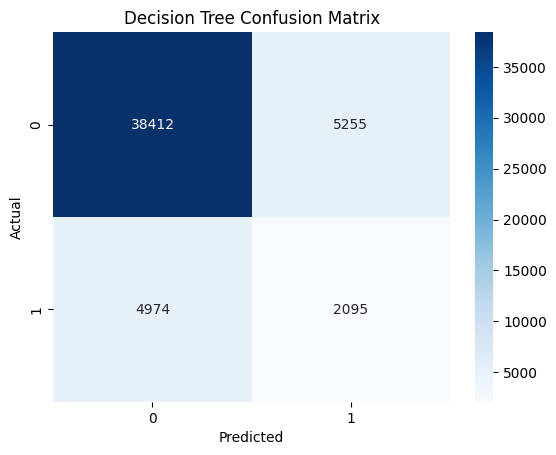

#**2. K-Nearest Neighbor (KNN)**

 Large dataset detected. Sampling 10,000 rows for KNN training...

 KNN (sampled) Performance 
Train Accuracy: 0.8904
Test Accuracy: 0.842

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91      1728
         1.0       0.32      0.14      0.19       272

    accuracy                           0.84      2000
   macro avg       0.60      0.55      0.55      2000
weighted avg       0.80      0.84      0.81      2000



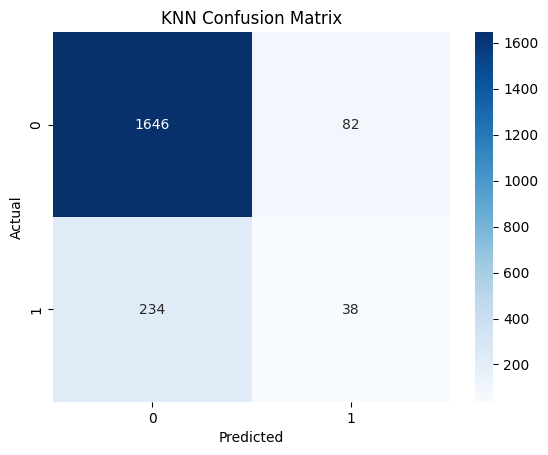

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dhi.csv")

# Automatically sample for KNN to prevent long runtimes
if len(df) > 20000:
    print(" Large dataset detected. Sampling 10,000 rows for KNN training...")
    df = df.sample(n=10000, random_state=42)

# Features and target
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred_train = knn.predict(X_train_scaled)
y_pred_test = knn.predict(X_test_scaled)

print("\n KNN (sampled) Performance ")
print("Train Accuracy:", round(accuracy_score(y_train, y_pred_train), 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_test), 4))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#**3. Random Forest**


Random Forest - Train Acc: 0.9998 | Test Acc: 0.8630
Precision: 0.48484848484848486
Recall: 0.11764705882352941
F1: 0.1893491124260355

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.88      0.98      0.93      1728
         1.0       0.48      0.12      0.19       272

    accuracy                           0.86      2000
   macro avg       0.68      0.55      0.56      2000
weighted avg       0.82      0.86      0.83      2000



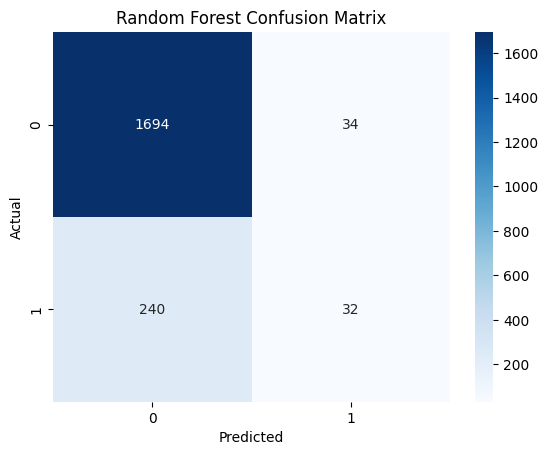

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

evaluate_model("Random Forest", y_train, rf.predict(X_train), y_test, rf.predict(X_test))

#**4.Voting Classifier**


Voting Classifier - Train Acc: 0.9359 | Test Acc: 0.8585
Precision: 0.47417840375586856
Recall: 0.3713235294117647
F1: 0.41649484536082476

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.90      0.94      0.92      1728
         1.0       0.47      0.37      0.42       272

    accuracy                           0.86      2000
   macro avg       0.69      0.65      0.67      2000
weighted avg       0.85      0.86      0.85      2000



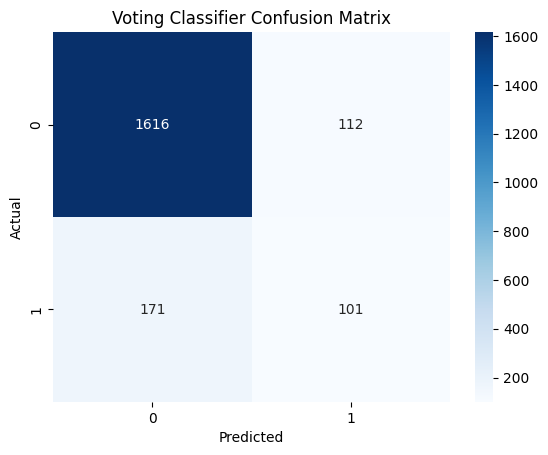

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
svc = SVC(probability=True, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

voting = VotingClassifier(estimators=[
    ('lr', lr), ('svc', svc), ('rf', rf)
], voting='soft')

voting.fit(X_train, y_train)

evaluate_model("Voting Classifier", y_train, voting.predict(X_train), y_test, voting.predict(X_test))

#**5. XGBoost**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:10:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost - Train Acc: 0.9496 | Test Acc: 0.8555
Precision: 0.43410852713178294
Recall: 0.20588235294117646
F1: 0.2793017456359102

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      1728
         1.0       0.43      0.21      0.28       272

    accuracy                           0.86      2000
   macro avg       0.66      0.58      0.60      2000
weighted avg       0.82      0.86      0.83      2000



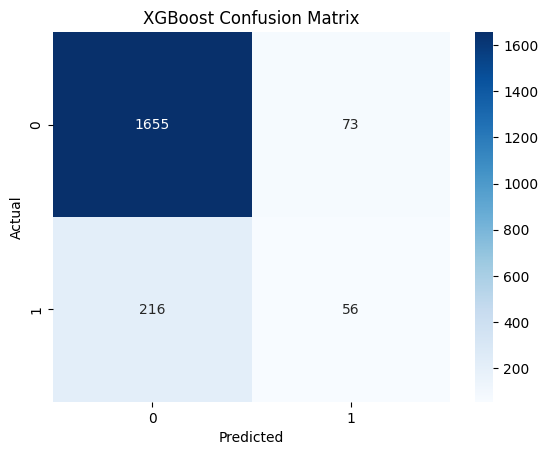

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

evaluate_model("XGBoost", y_train, xgb.predict(X_train), y_test, xgb.predict(X_test))

#**6.KMeans + Decision Tree**


KMeans + Decision Tree - Train Acc: 0.9998 | Test Acc: 0.7960
Precision: 0.2638888888888889
Recall: 0.27941176470588236
F1: 0.2714285714285714

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.89      0.88      0.88      1728
         1.0       0.26      0.28      0.27       272

    accuracy                           0.80      2000
   macro avg       0.57      0.58      0.58      2000
weighted avg       0.80      0.80      0.80      2000



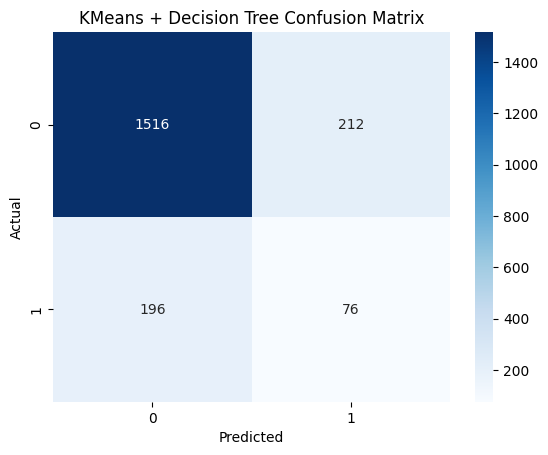

In [ ]:
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier

# Add cluster labels as new feature
kmeans = KMeans(n_clusters=2, random_state=42)
X_train_km = X_train.copy()
X_test_km = X_test.copy()
X_train_km['Cluster'] = kmeans.fit_predict(X_train)
X_test_km['Cluster'] = kmeans.predict(X_test)

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train_km, y_train)

evaluate_model("KMeans + Decision Tree", y_train, dt.predict(X_train_km), y_test, dt.predict(X_test_km))


#**7. KMeans + PCA**


KMeans + PCA - Train Acc: 0.9998 | Test Acc: 0.7960
Precision: 0.2638888888888889
Recall: 0.27941176470588236
F1: 0.2714285714285714

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.89      0.88      0.88      1728
         1.0       0.26      0.28      0.27       272

    accuracy                           0.80      2000
   macro avg       0.57      0.58      0.58      2000
weighted avg       0.80      0.80      0.80      2000



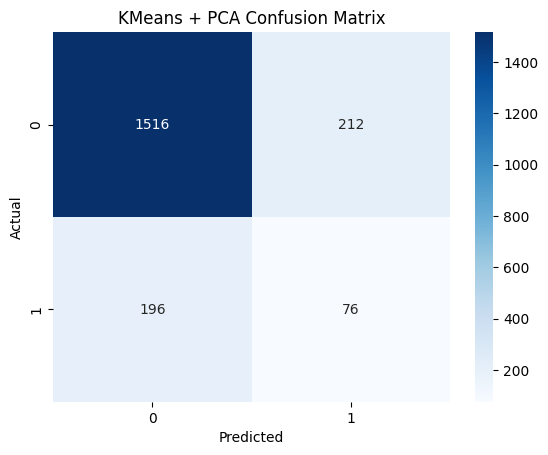

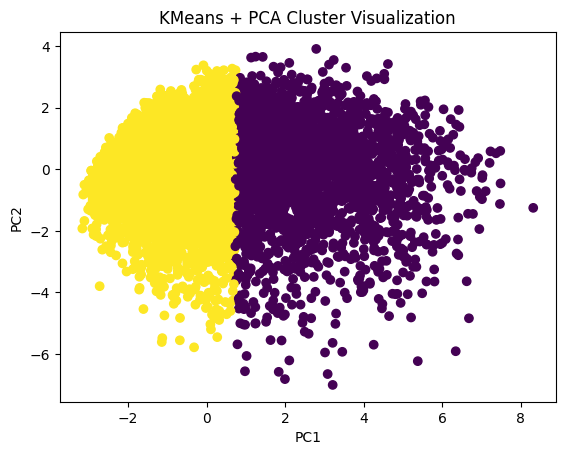

In [ ]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=2, random_state=42)
pca = PCA(n_components=2)
X_scaled = scaler.fit_transform(X)

X_pca = pca.fit_transform(X_scaled)
clusters = kmeans.fit_predict(X_pca)
evaluate_model("KMeans + PCA", y_train, dt.predict(X_train_km), y_test, dt.predict(X_test_km))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title('KMeans + PCA Cluster Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


#**8. Support Vector Machine (SVM)**


SVM - Train Acc: 0.6985 | Test Acc: 0.7000
Precision: 0.28534031413612565
Recall: 0.8014705882352942
F1: 0.42084942084942084

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.96      0.68      0.80      1728
         1.0       0.29      0.80      0.42       272

    accuracy                           0.70      2000
   macro avg       0.62      0.74      0.61      2000
weighted avg       0.87      0.70      0.75      2000



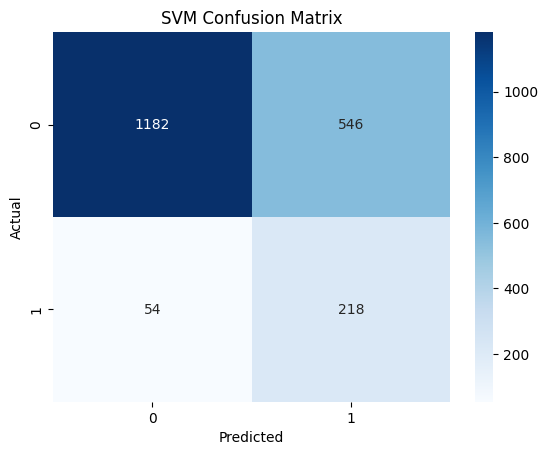

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)

evaluate_model("SVM", y_train, svm.predict(X_train), y_test, svm.predict(X_test))

#**9.KMeans + SVM**


KMeans + SVM - Train Acc: 0.6984 | Test Acc: 0.7000
Precision: 0.28534031413612565
Recall: 0.8014705882352942
F1: 0.42084942084942084

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.96      0.68      0.80      1728
         1.0       0.29      0.80      0.42       272

    accuracy                           0.70      2000
   macro avg       0.62      0.74      0.61      2000
weighted avg       0.87      0.70      0.75      2000



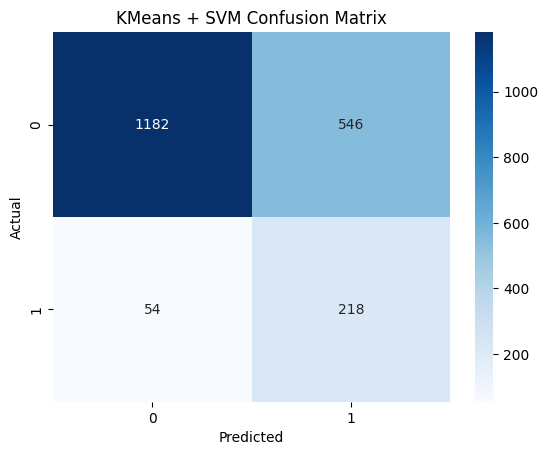

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
X_train_km = X_train.copy()
X_test_km = X_test.copy()
X_train_km['Cluster'] = kmeans.fit_predict(X_train)
X_test_km['Cluster'] = kmeans.predict(X_test)

svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train_km, y_train)

evaluate_model("KMeans + SVM", y_train, svm.predict(X_train_km), y_test, svm.predict(X_test_km))

#**10.Feed Forward Neural Network (MLP)**


Feed Forward Neural Network - Train Acc: 0.8895 | Test Acc: 0.8565
Precision: 0.4444444444444444
Recall: 0.22058823529411764
F1: 0.29484029484029484

Classification Report (Test):
               precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      1728
         1.0       0.44      0.22      0.29       272

    accuracy                           0.86      2000
   macro avg       0.67      0.59      0.61      2000
weighted avg       0.83      0.86      0.84      2000



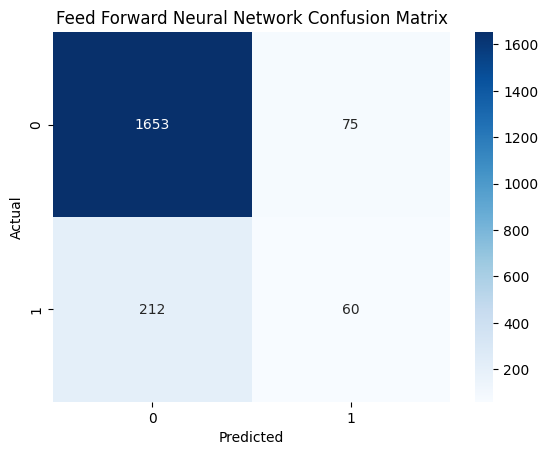

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                    max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

evaluate_model("Feed Forward Neural Network", y_train, mlp.predict(X_train), y_test, mlp.predict(X_test))